In [3]:
quiet_library <- function(...){suppressPackageStartupMessages(library(...))}
quiet_library(dplyr)
quiet_library(purrr)
quiet_library(tidyr)
quiet_library(data.table)
quiet_library(Seurat)
quiet_library(ggplot2)
quiet_library(glue)
quiet_library(gridExtra)
quiet_library(grid)
quiet_library(ggpubr)
quiet_library(clusterProfiler)
quiet_library(BaseSet)
quiet_library(jsonlite)
quiet_library(rrvgo)

options(repr.matrix.max.cols=150, repr.matrix.max.rows=200, mc.cores = 20, future.globals.maxSize = 2000 * 1024^2)
fig.size <- function (height, width) {
    options(repr.plot.height = height, repr.plot.width = width)
}

In [4]:
wd <- "/home/workspace/IFN"
fig_dir <- file.path(wd, "Figures")

In [5]:
set.seed(123)

In [6]:
stims <- c("IFNa", "IFNg")
celltypes <- c("Bcell", "Monocyte", "Tcell", "NK")
subtypes <- c("CD4 Naive", "CD8 Naive", "CD4 Memory", "CD8 Memory", "Treg", "gdT", "MAIT", "Naive", "Memory", "Plasma",
              "NK CD56dim", "NK CD56hi")
celltype_cols <- c("#00b4d8", "#1b4332", "#ffbf69", "#78290f" )
subtype_cols <- c("#03045e", "#023e8a", "#0077b6", "#0096c7", "#00b4d8", "#48cae4", "#90e0ef",
                   "#1b4332", "#52b788", "#b7e4c7",
                    "#ff9f1c", "#ffbf69", 
                   "#78290f"
                  )
stim_cols <- c("#e9c46a", "#f4a261", "#e76f51", "#264653", "#2a9d8f")

In [43]:
# cohort metadata
meta <- fread(file.path(wd, "Cohort_IFN_scores", "IFN_Cohort_Comparison_Sample_Sheet.csv")) %>% 
    filter(Group != "Control")


In [44]:
cohorts <- c("ALPS", "SLE_Science", "Acute_Covid", "Long_Covid", "Flu", "Malaria", 
             "RA_external", "BRI_aging_M", "BRI_aging_F", "MM_BMMC",
            "MM_Pretreatment", "MM_EndInduction", "RA", "SLE", "BRI", "MM_BMMC_Internal", "MM_BMMC_Internal_Healthy")

In [49]:
scores_df <- fread(file.path(wd, "Cohort_IFN_scores", "Cohort_IFN_Scores_Assembled.csv"))

In [75]:
scores_df_long$Misc2 <- recode(scores_df_long$Misc,
                        "M" = "Male", 
                        "F" = "Female",
                        "Flare" = "SLE Flare",
                          "Managed" = "SLE Managed", 
                        "Severe" = "COVID Severe",  
                        "Mild" = "COVID Mild", 
                        "Long" = "COVID Long",
                        "ACPA_pos" = "RA ACPA+", 
                        "ACPA_neg" = "RA ACPA-")

### 6B. L1 Boxplots INFa/g Score NDMM vs HC

In [31]:
# formatting and select cohorts
final_df_long <- scores_df %>% na.omit() %>%
    pivot_longer(!c(celltype, Cohort, KitID, SubjectID, Misc), names_to = "stim", values_to = "score") 
select_df <- final_df_long %>% filter(Cohort %in% c("MM_BMMC_Internal", "MM_BMMC_Internal_Healthy")) %>% na.omit()

select_df$Cohort <- recode(select_df$Cohort,
                               "MM_BMMC_Internal" = "NDMM",
                               "MM_BMMC_Internal_Healthy" = "Healthy")

Warning message in wilcox.test.default(c(0, 0, 0, 0, 0, 0, 0.247458114968651, 0.206619846002405, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0, 0, 0, 0, 0, 0, 0.0987588865081435, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0, 0, 0, 0, 0, 0.151009969987061, 0.125901739409476, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0, 0, 0.257663973954529, 0, 0, 0.0779485281811215, :
“cannot compute exact p-value with ties”
Warning message:
“Removed 20 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message in wilcox.test.default(c(0, 0, 0, 0, 0, 0, 0.211663637367492, 0.0455089228649744, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0, 0, 0, 0, 0, 0.158168147343057, 0.179624321583359, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0.0116911897346842,

null device 
          1

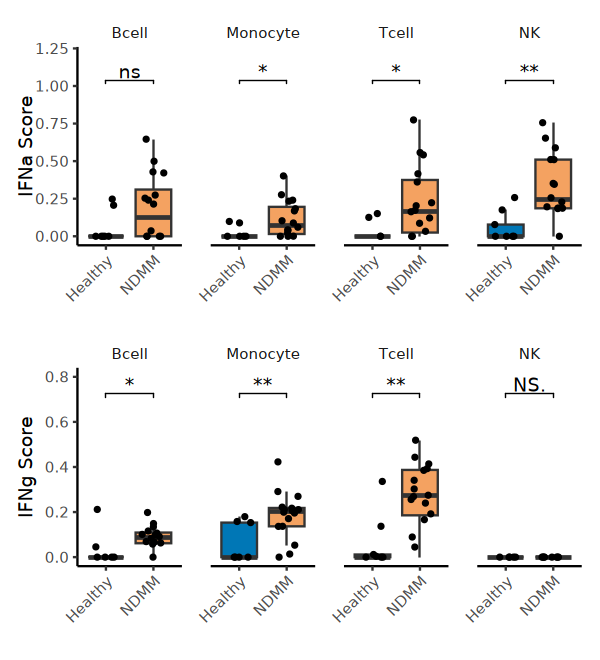

In [32]:
fig.size(5.5, 5)
#pdf(file.path(fig_dir, "Supp", "Sup6", "NDMM_Healthy_BMMC_IFNa_IFNg_Score_Boxplot.pdf"), height = 5.5, width = 5)
gg1 <- ggplot(select_df %>% filter(stim == "IFNa"), aes(x = Cohort, y = score, fill = Cohort)) +
    geom_boxplot(outlier.shape = NA) + 
    geom_jitter(width = 0.25, size = 1) + 
    ylim(0, 1.2) + 
    facet_wrap(~celltype, ncol = 4) + 
    scale_fill_manual(values = c("#0077b6", "#f4a261")) + 
    theme_classic() + 
    xlab("") + 
    ylab("IFNa Score") + 
    stat_compare_means(
      method = "wilcox.test",
      label = "p.signif",    
      size = 4,
      label.y = 1,
      comparisons = list(c("Healthy", "NDMM"))
    ) + 
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
          legend.position = "none",
          strip.background = element_blank(),
          panel.spacing = unit(1.2, "lines"))

gg2 <- ggplot(select_df %>% filter(stim == "IFNg"), aes(x = Cohort, y = score, fill = Cohort)) +
    geom_boxplot(outlier.shape = NA) + 
    geom_jitter(width = 0.25, size = 1) + 
    ylim(0, 0.8) + 
    facet_wrap(~celltype, ncol = 4) + 
    scale_fill_manual(values = c("#0077b6", "#f4a261")) + 
    theme_classic() + 
    xlab("") + 
    ylab("IFNg Score") + 
    stat_compare_means(
      method = "wilcox.test",
      label = "p.signif",     
      size = 4,
      label.y = 0.7,
      comparisons = list(c("Healthy", "NDMM"))
    ) + 
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
          legend.position = "none",
          strip.background = element_blank(),
          panel.spacing = unit(1.2, "lines"))

gg1 / gg2
dev.off()

### 6D. L1 Boxplots INFa/g Score Internal vs External MM

In [34]:
# formatting and select cohorts
final_df_long <- scores_df %>% na.omit() %>%
    pivot_longer(!c(celltype, Cohort, KitID, SubjectID, Misc), names_to = "stim", values_to = "score") 
select_df <- final_df_long %>% filter(Cohort %in% c("MM_BMMC_Internal") | Misc == "MM") %>% na.omit()



In [35]:
select_df$Cohort <- select_df$Cohort %>% recode("MM_BMMC" = "Zavidij 2020",
                                               "MM_BMMC_Internal" = "AIFI")


In [36]:
select_df$Cohort %>% table

.
        AIFI Zavidij 2020 
         128           56 

Warning message in wilcox.test.default(c(0.39614364266854, 0.19968476642588, 0.413097371841504, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.360837299599001, 0, 0.076768817798888, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.618728449116186, 0.180126152719989, 0.428814640379656, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.386103884448408, 0.0802045606231001, :
“cannot compute exact p-value with ties”
Warning message:
“Removed 11 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message in wilcox.test.default(c(0.0516550436194427, 0.0971082236547613, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0.0421243617985113, 0.0332527545256409, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.0858732258344951, 0.196747263797556, :
“cannot compute exact p-va

null device 
          1

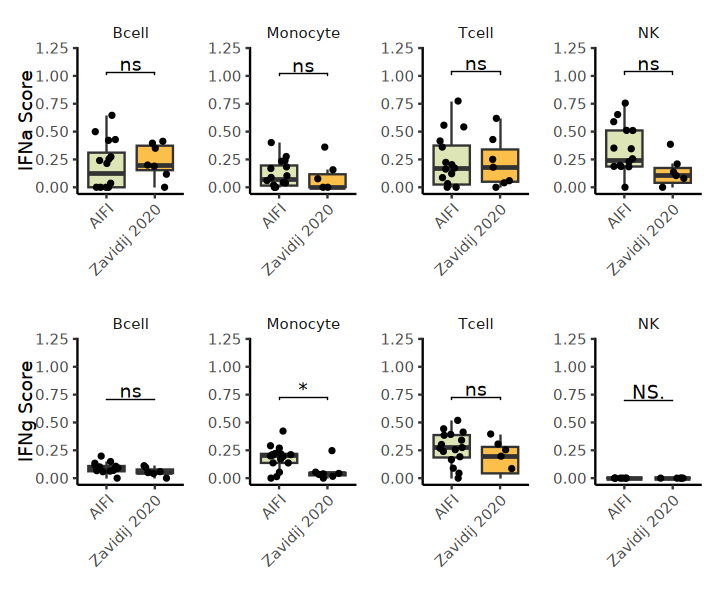

In [37]:
fig.size(5, 6)
#pdf(file.path(fig_dir, "Supp", "Sup6", "NDMM_Healthy_BMMC_IFNa_IFNg_Score_Boxplot.pdf"), height = 5, width = 6)
gg1 <- ggplot(select_df %>% filter(stim == "IFNa"), aes(x = Cohort, y = score, fill = Cohort)) +
    geom_boxplot(outlier.shape = NA) + 
    geom_jitter(width = 0.25, size = 1) + 
    ylim(0, 1.2) + 
    facet_wrap(~celltype, ncol = 4, scales = "free") + 
    scale_fill_manual(values = c("#dde5b6", "#fcbf49")) + 
    theme_classic() + 
    xlab("") + 
    ylab("IFNa Score") + 
    stat_compare_means(
      method = "wilcox.test",
      label = "p.signif",    
      size = 4,
      label.y = 1,
      comparisons = list(c("Zavidij 2020", "AIFI"))
    ) + 
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
          legend.position = "none",
          strip.background = element_blank(),
          panel.spacing = unit(1.2, "lines"))

gg2 <- ggplot(select_df %>% filter(stim == "IFNg"), aes(x = Cohort, y = score, fill = Cohort)) +
    geom_boxplot(outlier.shape = NA) + 
    geom_jitter(width = 0.25, size = 1) + 
    ylim(0, 1.2) + 
    facet_wrap(~celltype, ncol = 4, scales = "free") + 
    scale_fill_manual(values = c("#dde5b6", "#fcbf49")) + 
    theme_classic() + 
    xlab("") + 
    ylab("IFNg Score") + 
    stat_compare_means(
      method = "wilcox.test",
      label = "p.signif",     
      size = 4,
      label.y = 0.7,
      comparisons = list(c("Zavidij 2020", "AIFI"))
    ) + 
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
          legend.position = "none",
          strip.background = element_blank(),
          panel.spacing = unit(1.2, "lines"))

gg1 / gg2
dev.off()

### 6E. Myeloma IFN Score Boxplots

In [52]:
# format scores 
group_level <- c("M", "F", "Managed", "Flare", "ACPA_neg", "ACPA_pos", "Mild", "Severe", "Long", "Flu", 
                  "Malaria", "MM", "MGUS", "SMMh", "SMMl", "ALPS")
scores_df_long <- scores_df %>% filter(Misc %in% group_level) %>% 
    pivot_longer(!c(Cohort, celltype, KitID, SubjectID, Misc), names_to = "stim", values_to = "score")
scores_df_long$Misc <- factor(scores_df_long$Misc, levels = group_level)

In [54]:
scores_df_long$Misc <- as.character(scores_df_long$Misc)
scores_df_long$Misc <- ifelse(scores_df_long$Misc %in% c("SMMh", "SMMl"), "SMM", 
                               scores_df_long$Misc)

In [55]:
comparisons <- list(
  c("MM", "MGUS"),
  c("MM", "SMM"),
  c("MGUS", "SMM")
)

In [56]:
scores_df_long_select <- scores_df_long %>% filter(Cohort == "MM_BMMC")
scores_df_long_select$Misc <- factor(scores_df_long_select$Misc, levels = c("MGUS", "SMM", "MM"))

In [61]:
# IFNa plot
gg1 <- ggplot(scores_df_long_select %>% filter(stim == "IFNa"), 
              aes(x = Misc, y = score, fill = Misc)) +
  geom_boxplot(outlier.shape = NA) + 
  geom_jitter(width = 0.25, size = 1) + 
  ylim(0, 1) + 
  facet_wrap(~celltype, ncol = 4, scales = "free") + 
  theme_classic() + 
  xlab("") + ylab("IFNa Score") + 
  scale_fill_manual(values = c("#31572c", "#4f772d", "#ecf39e")) + 
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1),
    legend.position = "none", 
    strip.background = element_blank(),
    panel.spacing = unit(1, "lines"),
    panel.border = element_blank(),
    axis.line.y = element_line(color = "black")  # ensures y-axis line
  ) +
  stat_compare_means(comparisons = comparisons, 
                     method = "wilcox.test", 
                     label = "p.signif")

# IFNg plot
gg2 <- ggplot(scores_df_long_select %>% filter(stim == "IFNg"), 
              aes(x = Misc, y = score, fill = Misc)) +
  geom_boxplot(outlier.shape = NA) + 
  geom_jitter(width = 0.25, size = 1) + 
  ylim(0, 1) + 
  facet_wrap(~celltype, ncol = 4, scales = "free") + 
  theme_classic() + 
  xlab("") + ylab("IFNg Score") + 
  scale_fill_manual(values = c("#31572c", "#4f772d", "#ecf39e")) +   
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1),
    legend.position = "none", 
    strip.background = element_blank(),
    panel.spacing = unit(1, "lines"),
    panel.border = element_blank(),
    axis.line.y = element_line(color = "black")  # ensures y-axis line
  ) +
  stat_compare_means(comparisons = comparisons, 
                     method = "wilcox.test", 
                     label = "p.signif")



Warning message in wilcox.test.default(c(0.130192211741114, 0, 0.138635989649954, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.39614364266854, 0.19968476642588, 0.413097371841504, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.39614364266854, 0.19968476642588, 0.413097371841504, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0, 0, 0, 0, 0, 0, 0, 0, 0), c(0, 0.0181813509390877, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.360837299599001, 0, 0.076768817798888, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.360837299599001, 0, 0.076768817798888, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0, 0.0624438599658927, 0.23329615748002, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.386103884448408, 0.0802045606231001,

null device 
          1

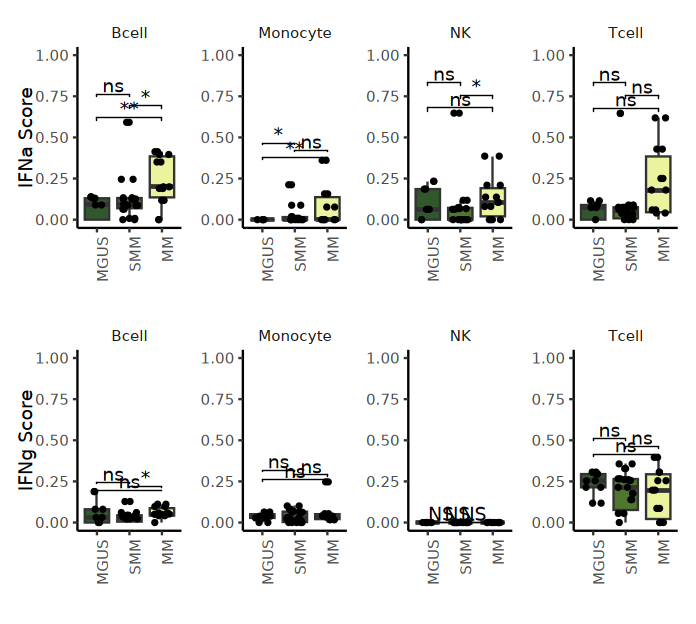

In [62]:
fig.size(5.2,5.8)
#pdf(file.path(fig_dir, "Fig6", "IFNa_g_Score_Myeloma_BoxPlots.pdf"), height = 5.2, width = 5.8)
gg1/gg2
dev.off()

In [93]:
results1 <- scores_df_long_select %>%
      group_by(celltype, stim) %>%
      group_split() %>%
      map_dfr(function(group_df) {
        map_dfr(comparisons, function(pair) {
          sub_df <- group_df %>% filter(Misc %in% pair)
          if (length(unique(sub_df$Misc)) == 2) {
            medians <- sub_df %>% group_by(Misc) %>% summarise(median_score = median(score), .groups = "drop")
            test <- wilcox.test(score ~ Misc, data = sub_df, paired = F)
            tibble(
              celltype = unique(group_df$celltype),
              stim = unique(group_df$stim),
              #DiseaseCohort = g,
              group1 = pair[1],
              group2 = pair[2],
              median_group1 = medians$median_score[medians$Misc2 == pair[1]],
              median_group2 = medians$median_score[medians$Misc2 == pair[2]],
              p_value = test$p.value
            )
          } 
        })
      }) %>% as.data.frame()

Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y

In [95]:
results1 %>%
    fwrite("Fig6_MM_IFN_Score_Wilcox_Results.csv")

### 6F. Infection IFN Score Boxplots

In [76]:
comparisons <- list(
  c("COVID Long", "COVID Mild"),
  c("COVID Severe", "COVID Mild"),
  c("COVID Severe", "COVID Long")
)

In [77]:
scores_df_long_select <- scores_df_long %>% 
                filter(Cohort %in% c("Acute_Covid", "Long_Covid", "Flu", "Malaria"))

In [78]:
# IFNa plot
gg1 <- ggplot(scores_df_long %>% filter(Cohort %in% c("Acute_Covid", "Long_Covid", "Flu", "Malaria") & stim == "IFNa"), 
              aes(x = Misc2, y = score, fill = Misc2)) +
  geom_boxplot(outlier.shape = NA) + 
  geom_jitter(width = 0.25, size = 1) + 
  ylim(0, 1) + 
  facet_wrap(~celltype, ncol = 4) + 
  theme_classic() + 
  xlab("") + ylab("IFNa Score") + 
  scale_fill_manual(values = c("#ee9b00", "#ca6702", "#bb3e03", "#ae2012", "#9b2226")) + 
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1),
    legend.position = "none", 
    strip.background = element_blank(),
    panel.spacing = unit(1, "lines"),
    panel.border = element_blank(),
    axis.line.y = element_line(color = "black")  # ensures y-axis line
  ) +
  stat_compare_means(comparisons = comparisons, 
                     method = "wilcox.test", 
                     label = "p.signif")

# IFNg plot
gg2 <- ggplot(scores_df_long %>% filter(Cohort %in% c("Acute_Covid", "Long_Covid", "Flu", "Malaria") & stim == "IFNg"), 
              aes(x = Misc2, y = score, fill = Misc2)) +
  geom_boxplot(outlier.shape = NA) + 
  geom_jitter(width = 0.25, size = 1) + 
  ylim(0, 1) + 
  facet_wrap(~celltype, ncol = 4) + 
  theme_classic() + 
  xlab("") + ylab("IFNg Score") + 
  scale_fill_manual(values = c("#ee9b00", "#ca6702", "#bb3e03", "#ae2012", "#9b2226")) + 
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1),
    legend.position = "none", 
    strip.background = element_blank(),
    panel.spacing = unit(1, "lines"),
    panel.border = element_blank(),
    axis.line.y = element_line(color = "black")  # ensures y-axis line
  ) +
  stat_compare_means(comparisons = comparisons, 
                     method = "wilcox.test", 
                     label = "p.signif")



Warning message in wilcox.test.default(c(0.138850886181821, 0.069961405319283, 0.0238846354501019, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0.124418610768136, 0, 0.00846145388428732, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0.124418610768136, 0, 0.00846145388428732, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0, 0.165854501310449, 0.1022300508166, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0.125928909208106, 0, 0.0276127915985684, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0.125928909208106, 0, 0.0276127915985684, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0.344147122589997, 0.173161783313379, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.0619526102585335, 0, 0, 0, 0, 0, 0, 0.00466071

null device 
          1

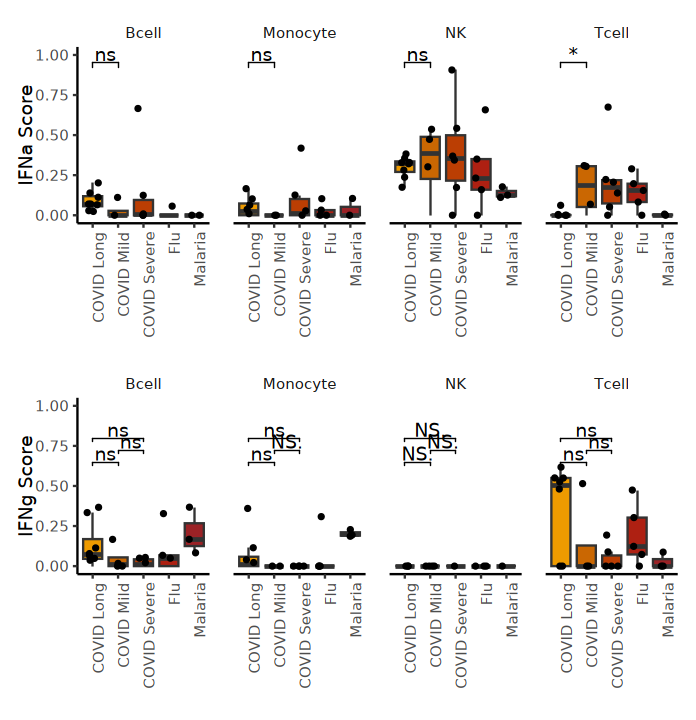

In [79]:
fig.size(6,5.8)
#pdf(file.path(fig_dir, "Fig6", "IFNa_g_Score_Infection_BoxPlots.pdf"), height = 6, width = 5.8)
gg1/gg2
dev.off()

In [119]:
results1 <- scores_df_long_select %>%
      group_by(celltype, stim) %>%
      group_split() %>%
      map_dfr(function(group_df) {
        map_dfr(comparisons, function(pair) {
          sub_df <- group_df %>% filter(Misc2 %in% pair)
          if (length(unique(sub_df$Misc2)) == 2) {
            medians <- sub_df %>% group_by(Misc2) %>% summarise(median_score = median(score), .groups = "drop")
            test <- wilcox.test(score ~ Misc2, data = sub_df, paired = F)
            tibble(
              celltype = unique(group_df$celltype),
              stim = unique(group_df$stim),
              #DiseaseCohort = g,
              group1 = pair[1],
              group2 = pair[2],
              median_group1 = medians$median_score[medians$Misc2 == pair[1]],
              median_group2 = medians$median_score[medians$Misc2 == pair[2]],
              p_value = test$p.value
            )
          } 
        })
      }) %>% as.data.frame()

Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”


In [116]:
results1 %>%
    fwrite("COVID_Wilcox_IFN_Score_Results.csv")